In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import segyio

In [2]:
# !git clone https://github.com/yohanesnuwara/d2geo

# import sys
# sys.path.append('/content/d2geo/attributes')

In [3]:
# from google.colab import drive
# drive.mount('/content/drive') # yohannesnuwara@gmail.com

In [4]:
def openSegy3D(filename, iline=189, xline=193):
  """
  Open 3D seismic volume in SEGY or SGY format 

  NOTE: Default byte location iline=189, xline=193
        If it returns "openSegy3D cannot read the data", change iline and xline
        Usually, specifying iline=5, xline=21 works
  """
  try:
    with segyio.open(filename) as f:

      data = segyio.tools.cube(f)

      inlines = f.ilines
      crosslines = f.xlines
      twt = f.samples
      sample_rate = segyio.tools.dt(f) / 1000

      print('Successfully read \n')
      print('Inline range from', inlines[0], 'to', inlines[-1])
      print('Crossline range from', crosslines[0], 'to', crosslines[-1])
      print('TWT from', twt[0], 'to', twt[-1])   
      print('Sample rate:', sample_rate, 'ms')  

      try:
        rot, cdpx, cdpy = segyio.tools.rotation(f, line="fast")
        print('Survey rotation: {:.2f} deg'.format(rot))      
      except:
        print("Survey rotation not recognized")  

      cube = dict({"data": data,
                   "inlines": inlines,
                   "crosslines": crosslines,
                   "twt": twt,
                   "sample_rate": sample_rate})
      
      # See Stackoverflow: https://stackoverflow.com/questions/4984647/accessing-dict-keys-like-an-attribute
      class AttrDict(dict):
          def __init__(self, *args, **kwargs):
              super(AttrDict, self).__init__(*args, **kwargs)
              self.__dict__ = self  

      cube = AttrDict(cube)

  except:
    try:
      # Specify iline and xline to segyio where to read
      with segyio.open(filename, iline=iline, xline=xline) as f:

        data = segyio.tools.cube(f)

        inlines = f.ilines
        crosslines = f.xlines
        twt = f.samples
        sample_rate = segyio.tools.dt(f) / 1000

        print('Successfully read \n')
        print('Inline range from', inlines[0], 'to', inlines[-1])
        print('Crossline range from', crosslines[0], 'to', crosslines[-1])
        print('TWT from', twt[0], 'to', twt[-1])   
        print('Sample rate:', sample_rate, 'ms')  

        try:
          rot, cdpx, cdpy = segyio.tools.rotation(f, line="fast")
          print('Survey rotation: {:.2f} deg'.format(rot))      
        except:
          print("Survey rotation not recognized")  

        cube = dict({"data": data,
                     "inlines": inlines,
                     "crosslines": crosslines,
                     "twt": twt,
                     "sample_rate": sample_rate})
        
        # See Stackoverflow: https://stackoverflow.com/questions/4984647/accessing-dict-keys-like-an-attribute
        class AttrDict(dict):
            def __init__(self, *args, **kwargs):
                super(AttrDict, self).__init__(*args, **kwargs)
                self.__dict__ = self  

        cube = AttrDict(cube)
    
    except:
      print("openSegy3D cannot read the data")
      cube = None

  return cube 

In [5]:
volve = '/store005/yohanuwa/Volve/ST0202R08_PZ_PSDM_FULL_OFFSET_DEPTH.MIG_FIN.POST_STACK.3D.JS-017534.segy'

cube = openSegy3D(filename=volve)

Successfully read 

Inline range from 9985 to 10369
Crossline range from 1932 to 2536
TWT from 0.0 to 4500.0
Sample rate: 5.0 ms
Survey rotation: 4.96 deg


In [6]:
# # The output is a dictionary
# cube

In [7]:
# Access the data and properties of output by ".attribute"
# The attributes are: .data, .inlines, .crosslines, .twt, .sample_rate
# Example 1: Access the inlines
print(cube.inlines)

# Example 2: Access the data
print(cube.data)

[ 9985  9986  9987  9988  9989  9990  9991  9992  9993  9994  9995  9996
  9997  9998  9999 10000 10001 10002 10003 10004 10005 10006 10007 10008
 10009 10010 10011 10012 10013 10014 10015 10016 10017 10018 10019 10020
 10021 10022 10023 10024 10025 10026 10027 10028 10029 10030 10031 10032
 10033 10034 10035 10036 10037 10038 10039 10040 10041 10042 10043 10044
 10045 10046 10047 10048 10049 10050 10051 10052 10053 10054 10055 10056
 10057 10058 10059 10060 10061 10062 10063 10064 10065 10066 10067 10068
 10069 10070 10071 10072 10073 10074 10075 10076 10077 10078 10079 10080
 10081 10082 10083 10084 10085 10086 10087 10088 10089 10090 10091 10092
 10093 10094 10095 10096 10097 10098 10099 10100 10101 10102 10103 10104
 10105 10106 10107 10108 10109 10110 10111 10112 10113 10114 10115 10116
 10117 10118 10119 10120 10121 10122 10123 10124 10125 10126 10127 10128
 10129 10130 10131 10132 10133 10134 10135 10136 10137 10138 10139 10140
 10141 10142 10143 10144 10145 10146 10147 10148 10

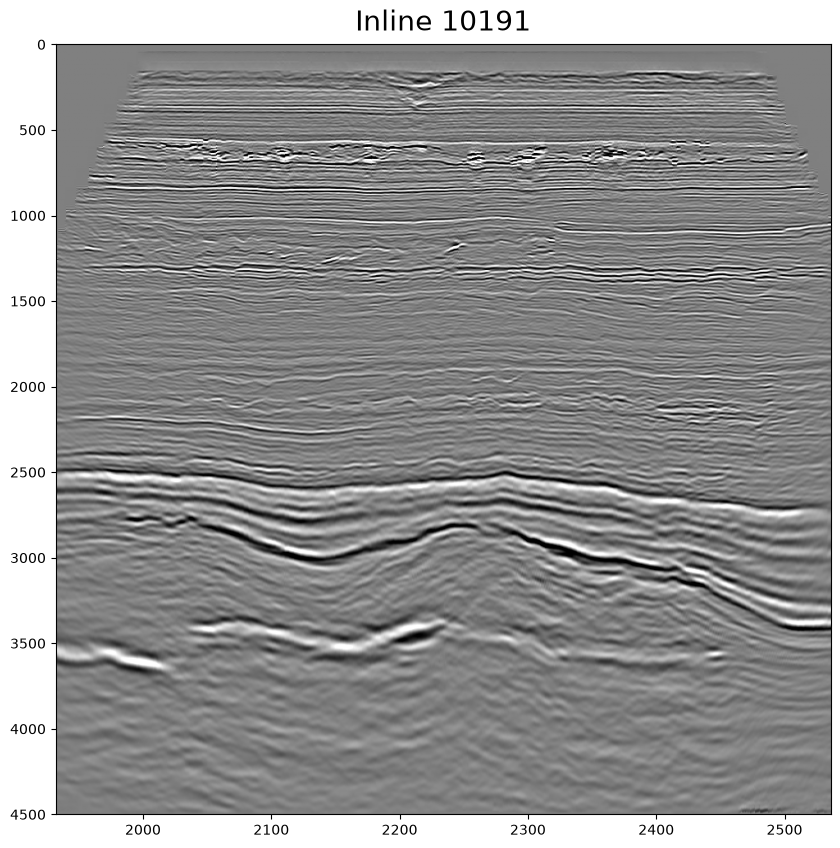

In [8]:
# Slicing data
inline_loc = 10191
data = cube.data
xlines, inlines, twt = cube.crosslines, cube.inlines, cube.twt

data_slice = data[inline_loc-inlines[0],:,:]

plt.figure(figsize=(10,10))
plt.imshow(data_slice.T, aspect='auto', vmin=-0.1, vmax=0.1, cmap='gray',
           extent=(xlines[0], xlines[-1], 4500, 0))
plt.title('Inline {}'.format(inline_loc), size=20, pad=10)

plt.show()

## Function

In [9]:
def slice_cube(cube, type='il', 
               inline_loc=400, inline_array=None,
               xline_loc=None, xline_array=None,
               timeslice_loc=None, timeslice_array=None,
               display='Yes', cmap='gray', figsize=None, vmin=None, vmax=None):
  
  """
  Slicing 3D seismic cube into 2D slice, and display it (optional)
  (Copyright, Y. Nuwara, ign.nuwara97@gmail.com)

  Input:

  cube: 3D seismic data output of segyio.tools.cube (3D numpy array)
  type: specify the type of slice
    * 'il' for inline
    * 'xl' for crossline
    * 'ts' for timeslice)

  inline_loc: preferred location of inline, if you specify type='il', 
              no need to input xline_loc, timeslice_loc
  xline_loc: preferred location of crossline, if you specify type='xl', 
             no need to input inline_loc, timeslice_loc
  timeslice_loc: preferred location of timeslice, if you specify type='ts', 
                 no need to input inline_loc, xline_loc
  
  inline_array: array of inline locations (output from segyio.read)
  xline_array: array of xline locations (output from segyio.read)
  timeslice_array: array of timeslice locations (output from segyio.read)

  display: Display option, specify 
    * 'Yes' if you want to display your slice.
    * 'No' if you don't want to display your slice, just to obtain the slice.

  If you specify 'Yes', configure the display details:
    * cmap: colormaps (Default is 'gray'. Other options 'seismic', 'RdBu', 'PuOr', etc)
    * figsize: figure size (2-size tuple. Default is None)
    * vmin: lowest limit for colormap (float/integer. Default is None)
    * vmax: upper limit for colormap (float/integer. Default is None)

  Output:

  slice: 2D numpy array, the slice, if display='No' is specified
  plt.show (seismic display), if display='Yes' is specified

  """

  import numpy as np
  import matplotlib.pyplot as plt

  if type == 'il':
    id = np.where(inline_array == inline_loc)[0][0]
    inline_slice = cube[id,:,:]
    
    if display == 'No':
      return(inline_slice)
        
    if display == 'Yes':
      plt.figure(figsize=figsize)
      plt.title('Dutch F3 Seismic at Inline {}'.format(inline_loc), size=20, pad=20)
      extent = [xline_array[0], xline_array[-1], timeslice_array[-1], timeslice_array[0]]

      p1 = plt.imshow(inline_slice.T, cmap=cmap, aspect='auto', extent=extent,
                      vmin=vmin, vmax=vmax)

      plt.xlabel('Crossline', size=15); plt.ylabel('TWT', size=15)
      plt.show()

  if type == 'xl':

    id = np.where(xline_array == xline_loc)[0][0]
    xline_slice = cube[:,id,:]

    if display == 'No':
      return(xline_slice)
    
    if display == 'Yes':
      plt.figure(figsize=figsize)
      plt.title('Dutch F3 Seismic at Crossline {}'.format(xline_loc), size=20, pad=20)
      extent = [inline_array[0], inline_array[-1], timeslice_array[-1], timeslice_array[0]]

      p1 = plt.imshow(xline_slice.T, cmap=cmap, aspect='auto', extent=extent, 
                      vmin=vmin, vmax=vmax)

      plt.xlabel('Inline', size=15); plt.ylabel('TWT', size=15)
      plt.show()
  
  if type == 'ts':

    id = np.where(timeslice_array == timeslice_loc)[0][0]
    tslice = cube[:,:,id]

    if display == 'No':
      return(tslice)

    if display == 'Yes':

      plt.figure(figsize=figsize)
      plt.title('Dutch F3 Seismic at Timeslice {} ms'.format(timeslice_loc), size=20, pad=20)
      extent = [inline_array[0], inline_array[-1], xline_array[-1], xline_array[0]]

      p1 = plt.imshow(tslice.T, cmap=cmap, aspect='auto', extent=extent, 
                      vmin=vmin, vmax=vmax)

      plt.xlabel('Inline', size=15); plt.ylabel('Crossline', size=15)
      plt.xlim(min(inline_array), max(inline_array))
      plt.ylim(min(xline_array), max(xline_array))
      plt.axis('equal')
      plt.show()  

def compute_attribute(cube, output='2d', type='il',
                      inline_loc=400, inline_array=None,
                      xline_loc=1000, xline_array=None,
                      timeslice_loc=1404, timeslice_array=None,
                      attribute_class='CompleTrace',
                      attribute_type='cosphase', kernel=None, sample_rate=4,
                      dip_factor=10, axis=-1):
  """
  Computing attribute of a 3D cube, output a 2D attribute slice
  (Copyright, Y. Nuwara, ign.nuwara97@gmail.com)

  Input:

  cube: 3D seismic data output of segyio.tools.cube (3D numpy array)
  type: specify the type of slice
    * 'il' for inline
    * 'xl' for crossline
    * 'ts' for timeslice)
  inline_loc: preferred location of inline, if you specify type='il',
              no need to input xline_loc, timeslice_loc
  xline_loc: preferred location of crossline, if you specify type='xl',
             no need to input inline_loc, timeslice_loc
  timeslice_loc: preferred location of timeslice, if you specify type='ts',
                 no need to input inline_loc, xline_loc
  inline_array: array of inline locations (segyio.read output), if you specify
                type='il', no need to input xline_array, timeslice_array
  xline_array: array of crossline locations (segyio.read output), if you specify
               type='xl', no need to input inline_array, timeslice_array
  timeslice_array: array of twt (segyio.read output), if you specify
                   type='ts', no need to input inline_array, xline_array

  attribute_class: specify the class of attribute (string)
    * 'Amplitude': amplitude attributes
    * 'CompleTrace': complex trace attributes
    * 'DipAzm': dip and azimuth attributes
    * 'EdgeDetection': edge detection attributes

  attribute_type: specify the attribute type (string).

  Note. Please read DOCS for input-output (i/o) of each attribute, here:
  https://github.com/yohanesnuwara/computational-geophysics/edit/master/seismic/README.md

  Each class has different attribute types, as follows.

    * For class 'Amplitude', attributes are:

      * 'fder': first derivative
      * 'sder': second derivative
      * 'rms': rms of trace value (e.g. amplitude)
      * 'gradmag': gradient magnitude using Gaussian operator
      * 'reflin': reflection intensity

    * For class 'CompleTrace', attributes are:
      * 'enve': envelope
      * 'inphase': instantaneous phase
      * 'cosphase': cosine instantaneous phase
      * 'ampcontrast': relative amplitude contrast
      * 'ampacc': amplitude acceleration
      * 'infreq': instantaneous frequency
      * 'inband': instantaneous bandwidth
      * 'domfreq': dominant frequency
      * 'freqcontrast': frequency change
      * 'sweet': sweetness
      * 'quality': quality factor
      * 'resphase': response phase
      * 'resfreq': response frequency
      * 'resamp': response amplitude
      * 'apolar': apparent polarity

    * For class 'DipAzm', attributes are:
      * 'dipgrad': gradient dips from inline, crossline, and z-gradients
      * 'gst': the gradient structure tensors (GST), inner product of
        gradients.
      * 'gstdip2d': 2D gradient dips from GST
      * 'gstdip3d': 3D gradient dips from GST
      * 'gstazm3d': 3D azimuth from GST

    * For class 'EdgeDetection', attributes are:
      * 'semblance': semblance
      * 'gstdisc': discontinuity from eigenvalues of GST
      * 'eigen': multi-trace semblance from 3D seismic incorporating the
                analytic trace
      * 'chaos': multi-trace chaos from 3D seismic
      * 'curv': volume curvature from 3D seismic dips

  """

  import numpy as np
  import segyio

  from attributes.CompleTrace import ComplexAttributes
  from attributes.DipAzm import DipAzm
  from attributes.EdgeDetection import EdgeDetection
  from attributes.Frequency import Frequency
  from attributes.SignalProcess import SignalProcess

  """
  Functions
  """

  def make_dask(darray, output, attribute_class, attribute_type, kernel):

    if output == '2d':

      if attribute_class == 'Amplitude':
        x = SignalProcess()
        darray, chunks_init = SignalProcess.create_array(x, darray, kernel,
                                                         preview=None)
        darray = darray.T

      if attribute_class == 'CompleTrace':
        x = ComplexAttributes()
        darray, chunks_init = ComplexAttributes.create_array(x, darray, kernel,
                                                             preview=None)
        darray = darray.T

      if attribute_class == 'DipAzm':
        x = DipAzm()
        darray, chunks_init = DipAzm.create_array(x, darray, kernel=None,
                                                  preview=None)
        darray = darray.T

      if attribute_class == 'EdgeDetection':
        x = EdgeDetection()
        darray, chunks_init = EdgeDetection.create_array(x, darray, kernel,
                                                         preview=None)
        darray = darray.T

    if output == '3d':

      if attribute_class == 'Amplitude':
        x = SignalProcess()
        darray, chunks_init = SignalProcess.create_array(x, darray, kernel,
                                                         preview=None)

      if attribute_class == 'CompleTrace':
        x = ComplexAttributes()
        darray, chunks_init = ComplexAttributes.create_array(x, darray, kernel,
                                                             preview=None)

      if attribute_class == 'DipAzm':
        x = DipAzm()
        darray, chunks_init = DipAzm.create_array(x, darray, kernel=None,
                                                  preview=None)

      if attribute_class == 'EdgeDetection':
        x = EdgeDetection()
        darray, chunks_init = EdgeDetection.create_array(x, darray, kernel,
                                                         preview=None)

    return(x, darray)


  def compute(x, darray, attribute_class, attribute_type, kernel,
              sample_rate, dip_factor, axis):

    if attribute_class == 'Amplitude':

      if attribute_type == 'fder':
        result = SignalProcess.first_derivative(x, darray, axis=-1,
                                                preview=None)
        return(result)

      if attribute_type == 'sder':
        result = SignalProcess.second_derivative(x, darray, axis=-1,
                                                 preview=None)
        return(result)

      if attribute_type == 'rms':
        result = SignalProcess.rms(x, darray, kernel=(1,1,9),
                                   preview=None)
        return(result)

      if attribute_type == 'gradmag':
        result = SignalProcess.gradient_magnitude(x, darray, sigmas=(1,1,1),
                                                  preview=None)
        return(result)

      if attribute_type == 'reflin':
        result = SignalProcess.reflection_intensity(x, darray, kernel=(1,1,9),
                                                    preview=None)
        return(result)

    if attribute_class == 'CompleTrace':

      if attribute_type == 'enve':
        result = ComplexAttributes.envelope(x, darray, preview=None)
        return(result)

      if attribute_type == 'inphase':
        result = ComplexAttributes.instantaneous_phase(x, darray, preview=None)
        return(result)

      if attribute_type == 'cosphase':
        result = ComplexAttributes.cosine_instantaneous_phase(x, darray,
                                                              preview=None)
        return(result)

      if attribute_type == 'ampcontrast':
        result = ComplexAttributes.relative_amplitude_change(x, darray,
                                                             preview=None)
        return(result)

      if attribute_type == 'ampacc':
        result = ComplexAttributes.amplitude_acceleration(x, darray,
                                                          preview=None)
        return(result)

      if attribute_type == 'infreq':
        result = ComplexAttributes.instantaneous_frequency(x, darray,
                                                           sample_rate=4,
                                                           preview=None)
        return(result)

      if attribute_type == 'inband':
        result = ComplexAttributes.instantaneous_bandwidth(x, darray,
                                                           preview=None)
        return(result)

      if attribute_type == 'domfreq':
        result = ComplexAttributes.dominant_frequency(x, darray, sample_rate=4,
                                                      preview=None)
        return(result)

      if attribute_type == 'freqcontrast':
        result = ComplexAttributes.dominant_frequency(x, darray, sample_rate=4,
                                                      preview=None)
        return(result)

      if attribute_type == 'sweet':
        result = ComplexAttributes.sweetness(x, darray, sample_rate=4,
                                             preview=None)
        return(result)

      if attribute_type == 'quality':
        result = ComplexAttributes.quality_factor(x, darray, sample_rate=4,
                                                  preview=None)
        return(result)

      if attribute_type == 'resphase':
        result = ComplexAttributes.response_phase(x, darray, preview=None)
        return(result)

      if attribute_type == 'resfreq':
        result = ComplexAttributes.response_frequency(x, darray, sample_rate=4,
                                                      preview=None)
        return(result)

      if attribute_type == 'resamp':
        result = ComplexAttributes.response_amplitude(x, darray, preview=None)
        return(result)

      if attribute_type == 'apolar':
        result = ComplexAttributes.apparent_polarity(x, darray, preview=None)
        return(result)

    if attribute_class == 'DipAzm':

      if attribute_type == 'dipgrad':
        result = DipAzm.gradient_dips(x, darray, dip_factor=10, kernel=(3,3,3),
                                      preview=None)
        return(result) # result is il_dip, xl_dip

      if attribute_type == 'gst':
        result = DipAzm.gradient_structure_tensor(x, darray, kernel,
                                                  preview=None)
        return(result) # result is gi2, gj2, gk2, gigj, gigk, gjgk

      if attribute_type == 'gstdip2d':
        result = DipAzm.gst_2D_dips(x, darray, dip_factor=10, kernel=(3,3,3),
                                    preview=None)
        return(result) # result is il_dip, xl_dip

      if attribute_type == 'gstdip3d':
        result = DipAzm.gst_3D_dip(x, darray, dip_factor=10, kernel=(3,3,3),
                                   preview=None)
        return(result)

      if attribute_type == 'gstazm3d':
        result = DipAzm.gst_3D_azm(x, darray, dip_factor=10, kernel=(3,3,3),
                                   preview=None)
        return(result)


    if attribute_class == 'EdgeDetection':

      if attribute_type == 'semblance':
        result = EdgeDetection.semblance(x, darray, kernel=(3,3,9),
                                         preview=None)
        return(result)

      if attribute_type == 'gstdisc':
        result = EdgeDetection.gradient_structure_tensor(x, darray,
                                                         kernel=(3,3,9),
                                                         preview=None)
        return(result)

      if attribute_type == 'eigen':
        result = EdgeDetection.eig_complex(x, darray, kernel=(3,3,9),
                                           preview=None)
        return(result)

      if attribute_type == 'chaos':
        result = EdgeDetection.chaos(x, darray, kernel=(3,3,9),
                                     preview=None)
        return(result)

      if attribute_type == 'curv':
        # compute first inline and xline dips from gst
        x = DipAzm()
        darray_il, darray_xl = DipAzm.gradient_dips(x, darray, dip_factor=10,
                                                    kernel=(3,3,3),
                                                    preview=None)
        # compute curvature
        result = EdgeDetection.volume_curvature(x, darray_il, darray_xl,
                                                dip_factor=10,
                                                kernel=(3,3,3),
                                                preview=None)
        return(result) # result is H, K, Kmax, Kmin, KMPos, KMNeg

  """
  Main Program
  """

  if output == '3d':

    # 3D cube is directly as input to compute attribute function

    darray = cube
    x, darray = make_dask(darray, output, attribute_class,
                          attribute_type, kernel)
    result = compute(x, cube, attribute_class, attribute_type, kernel,
                     sample_rate, dip_factor, axis)

  if output == '2d':

    # slicing the 3D cube based on inline, crossline, or timeslice selection
    # processing input to attribute computation
    # then compute attribute

    if type == 'il':
      slices = slice_cube(cube, type, inline_loc, inline_array, display='No')

      darray = np.reshape(slices, slices.shape + (1,))

      x, darray = make_dask(darray, output, attribute_class,
                            attribute_type, kernel)
      result = compute(x, darray, attribute_class, attribute_type,
                       kernel, sample_rate, dip_factor, axis)

    if type == 'xl':
      slices = slice_cube(cube, type, xline_loc, xline_array, display='No')

      darray = np.reshape(slices, slices.shape + (1,))

      x, darray = make_dask(darray, output, attribute_class,
                            attribute_type, kernel)
      result = compute(x, darray, attribute_class, attribute_type,
                       kernel, sample_rate, dip_factor, axis)

    if type == 'ts':
      slices = slice_cube(cube, type,
                          timeslice_loc=timeslice_loc,
                          timeslice_array=timeslice_array,
                          display='No')

      darray = np.reshape(np.transpose(slices),
                          (np.transpose(slices)).shape + (1,))

      x, darray = make_dask(darray, output, attribute_class,
                            attribute_type, kernel)
      result = compute(x, darray, attribute_class, attribute_type,
                       kernel, sample_rate, dip_factor, axis)

  return result

## Attribute calculation

In [10]:

    # * For class 'Amplitude', attributes are:

    #   * 'fder': first derivative
    #   * 'sder': second derivative
    #   * 'rms': rms of trace value (e.g. amplitude)
    #   * 'gradmag': gradient magnitude using Gaussian operator
    #   * 'reflin': reflection intensity

    # * For class 'CompleTrace', attributes are:
    #   * 'enve': envelope
    #   * 'inphase': instantaneous phase
    #   * 'cosphase': cosine instantaneous phase
    #   * 'ampcontrast': relative amplitude contrast
    #   * 'ampacc': amplitude acceleration
    #   * 'infreq': instantaneous frequency
    #   * 'inband': instantaneous bandwidth
    #   * 'domfreq': dominant frequency
    #   * 'freqcontrast': frequency change
    #   * 'sweet': sweetness
    #   * 'quality': quality factor
    #   * 'resphase': response phase
    #   * 'resfreq': response frequency
    #   * 'resamp': response amplitude
    #   * 'apolar': apparent polarity

    # * For class 'DipAzm', attributes are:
    #   * 'dipgrad': gradient dips from inline, crossline, and z-gradients
    #   * 'gst': the gradient structure tensors (GST), inner product of
    #     gradients.
    #   * 'gstdip2d': 2D gradient dips from GST
    #   * 'gstdip3d': 3D gradient dips from GST
    #   * 'gstazm3d': 3D azimuth from GST

    # * For class 'EdgeDetection', attributes are:
    #   * 'semblance': semblance
    #   * 'gstdisc': discontinuity from eigenvalues of GST
    #   * 'eigen': multi-trace semblance from 3D seismic incorporating the
    #             analytic trace
    #   * 'chaos': multi-trace chaos from 3D seismic
    #   * 'curv': volume curvature from 3D seismic dips


In [11]:
attr_cube = compute_attribute(cube.data, output='3d',
                      attribute_class='CompleTrace',
                      attribute_type='sweet', )

In [12]:
attr_cube.shape

(385, 605, 925)

In [13]:
print("attr_cube shape:", attr_cube.shape)
print("attr_cube chunks:", attr_cube.chunks)

attr_cube shape: (385, 605, 925)
attr_cube chunks: ((384, 1), (384, 1, 220), (925,))


In [14]:
cube.data.shape

(385, 605, 901)

In [15]:
# Size in GB
size_gb = attr_cube.nbytes / (1024**3)
print(f"Size: {size_gb:.2f} GB")

Size: 0.80 GB


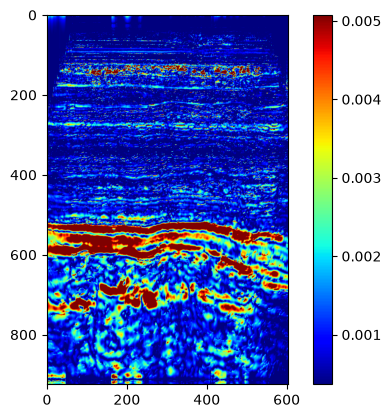

In [16]:
attr_slice = attr_cube[100,:,:].T
attr_slice_computed = attr_slice.compute()
vm = np.percentile(attr_slice_computed, 99)
vmin_plot = np.percentile(attr_slice_computed, 25)
vmax_plot = np.percentile(attr_slice_computed, 95)

plt.imshow(attr_cube[100,:,:].T, cmap='jet', vmin=vmin_plot, vmax=vmax_plot)
plt.colorbar()

In [17]:
attr_slice

dask.array<transpose, shape=(925, 605), dtype=float32, chunksize=(925, 384), chunktype=numpy.ndarray>

In [18]:
# convert attr_cube into npy and save to drive
import numpy as np

# Path to save the file in Drive
save_path = 'output/volve_psdm_attribute_cube_sweetness.npy'

# Compute the dask array into a numpy array
attr_npy = attr_cube.compute()

# Save as .npy file
np.save(save_path, attr_npy)
print(f"Successfully saved to {save_path}")


Successfully saved to output/volve_psdm_attribute_cube_sweetness.npy


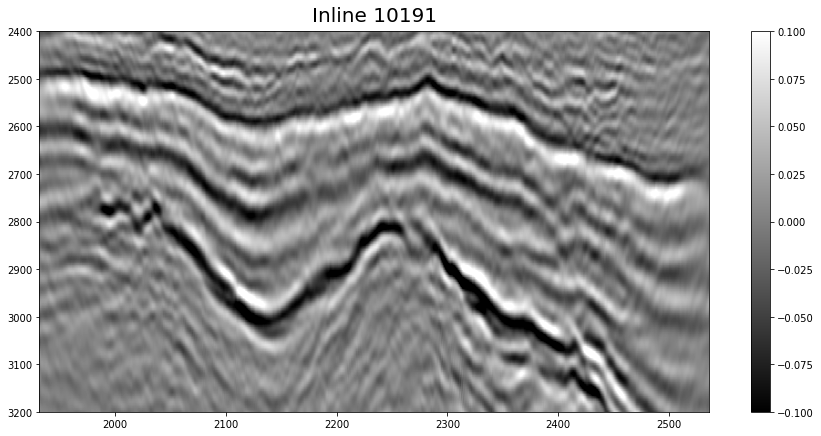

In [ ]:
# Slicing data
inline_loc = 10191
data = cube.data
xlines, inlines, twt = cube.crosslines, cube.inlines, cube.twt

data_slice = data[inline_loc-inlines[0],:,:]

plt.figure(figsize=(15,7))
plt.imshow(data_slice.T, aspect='auto', vmin=-0.1, vmax=0.1, cmap='gray',
           extent=(xlines[0], xlines[-1], 4500, 0))
plt.title('Inline {}'.format(inline_loc), size=20, pad=10)
plt.ylim(3200, 2400)

plt.colorbar()
plt.show()

In [ ]:
result = compute_attribute(cube=data, output='2d', type='il', inline_loc=10191,
                      inline_array=inlines, kernel=(10,2,1),
                      attribute_class='CompleTrace', attribute_type='enve')
result

dask.array<_trim, shape=(1, 905, 625), dtype=float32, chunksize=(1, 582, 605), chunktype=numpy.ndarray>

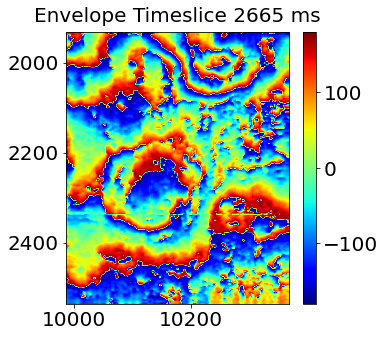

In [ ]:
plt.rcParams['font.size'] = 20

result = compute_attribute(cube=data, output='2d', type='ts', timeslice_loc=2665.,
                      timeslice_array=twt, kernel=(10,2,1),
                      attribute_class='CompleTrace', attribute_type='inphase')

# Plot attribute section
plt.figure(figsize=(5,5))

vmin, vmax = 0, 20 # -0.2, 0.2
vmin, vmax = None, None
# display_attribute(result, 'il', xlines, twt, 'jet', vmin, vmax)
display_attribute(result, cube, 'ts', 'jet', vmin, vmax)
plt.title('Envelope Timeslice {} ms'.format(2665), size=20, pad=10)
# plt.ylim(3200, 2400)

plt.show()

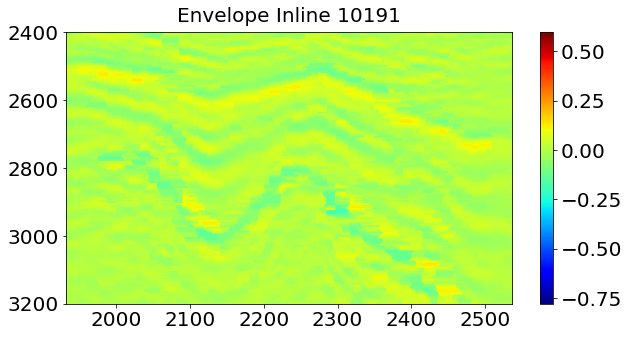

In [ ]:
# Calculate attribute
result = compute_attribute(cube=data, output='2d', type='il', inline_loc=10191,
                      inline_array=inlines, kernel=(10,2,1),
                      attribute_class='CompleTrace', attribute_type='resamp')

# Plot attribute section
plt.figure(figsize=(10,5))

vmin, vmax = 0, 30 # -0.2, 0.2
vmin, vmax = None, None
display_attribute(result, cube, 'il', 'jet', vmin, vmax)
plt.title('Envelope Inline {}'.format(inline_loc), size=20, pad=10)
plt.ylim(3200, 2400)

plt.show()

In [ ]:
# # Calculate attribute
# result = compute_attribute(cube=data, output='2d', type='il', inline_loc=10191,
#                       inline_array=inlines, kernel=(10,2,1),
#                       attribute_class='CompleTrace', attribute_type='quality')

# # Plot attribute section
# plt.figure(figsize=(10,5))

# vmin, vmax = -0.5e3, 0.5e3 # -0.2, 0.2
# # vmin, vmax = None, None
# display_attribute(result, cube, 'il', 'jet', vmin, vmax)
# plt.title('Quality Factor Inline {}'.format(inline_loc), size=20, pad=10)
# plt.ylim(3200, 2400)

# plt.show()

## Various attributes for clustering dataset preparation

In [ ]:
# atts = ['inphase', 'enve', 'infreq', 'resfreq', 'apolar']

# all_atts = []
# for i in range(5):
#   # Calculate attribute
#   result = compute_attribute(cube=data, output='2d', type='il', inline_loc=10191,
#                         inline_array=inlines, kernel=(10,2,1),
#                         attribute_class='CompleTrace', attribute_type=atts[i])
#   all_atts.append(result.compute().reshape(-1))

# inphase, enve, infreq, resfreq, apolar = all_atts

In [ ]:
atts = ['inphase', 'enve', 'infreq', 'apolar', 'resamp']

all_atts = []
for i in range(5):
  # Calculate attribute
  result = compute_attribute(cube=data, output='2d', type='il', inline_loc=10191,
                        inline_array=inlines, kernel=(10,2,1),
                        attribute_class='CompleTrace', attribute_type=atts[i])
  # print(result.compute().shape)
  all_atts.append(result.compute().reshape(-1))

inphase, enve, infreq, apolar, resamp = all_atts

In [ ]:
np.savetxt('five_attributes2.txt', np.transpose(all_atts), fmt='%2f')

In [ ]:
x = np.loadtxt('/content/five_attributes2.txt')

In [ ]:
cube.data.shape

(385, 605, 901)

In [ ]:
result.compute

<bound method DaskMethodsMixin.compute of dask.array<where, shape=(1, 905, 625), dtype=float32, chunksize=(1, 582, 605), chunktype=numpy.ndarray>>